# Land Cover Classification Using Python

This notebook demonstrates a complete Python-based workflow for satellite image processing and land cover classification using Landsat 9 multispectral imagery. The workflow includes loading raster datasets, generating True Color Composite (TCC) and False Color Composite (FCC) images, computing the Normalized Difference Vegetation Index (NDVI), extracting training samples from Region of Interests (ROIs), performing Random Forest Classification, assessing classification accuracy, and comparing the results with the QGIS-based classification workflow.

The implementation utilizes open-source Python libraries including Rasterio, GeoPandas, NumPy, Matplotlib, Pandas, and Scikit-learn to automate the complete land cover classification process

## 1. Import Libraries

In [2]:
# Numerical Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Raster Processing
import rasterio
from rasterio.plot import show
from rasterio.mask import mask

# Vector Data Processing
import geopandas as gpd

# Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Accuracy Assessment
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score
)

# Standard Libraries
from pathlib import Path

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Configuration

In [ ]:
# Project Directories

PROJECT_ROOT = Path.cwd().parent.parent

QGIS_DIR = PROJECT_ROOT / "QGIS Project"
PYTHON_DIR = PROJECT_ROOT / "Python"

SUBSET_DIR = QGIS_DIR / "Subset_Data"
TRAINING_DIR = QGIS_DIR / "Classification"/ "Training_Data"
VALIDATION_DIR = QGIS_DIR / "Classification" / "Validation_Data"

OUTPUT_DIR = PYTHON_DIR / "Outputs"
RGB_OUTPUT = OUTPUT_DIR / "RGB_Composite"
NDVI_OUTPUT = OUTPUT_DIR / "NDVI"
CLASSIFICATION_OUTPUT = OUTPUT_DIR / "Classification"
MODEL_OUTPUT = OUTPUT_DIR / "Models"

## 3. Load Landsat 9 Data

The first step in the Python workflow is to load the preprocessed Landsat 9 multispectral raster bands. To maintain consistency with the QGIS-based workflow presented in Chapter 4, the subsetted raster bands generated after clipping the original Landsat scene to the Area of Interest (AOI) are used as the input dataset.

The following six spectral bands are utilized throughout the analysis:

| Band | Spectral Region |
|------|-----------------|
| Band 2 | Blue |
| Band 3 | Green |
| Band 4 | Red |
| Band 5 | Near Infrared (NIR) |
| Band 6 | Shortwave Infrared-1 (SWIR-1) |
| Band 7 | Shortwave Infrared-2 (SWIR-2) |

These raster bands are loaded using the Rasterio library and stored as file paths for subsequent image processing and classification.

In [ ]:
# Landsat 9 Jodhpur Subset Bands

band_2 = SUBSET_DIR / "Jodhpur_Subset_B2.tif"
band_3 = SUBSET_DIR / "Jodhpur_Subset_B3.tif"
band_4 = SUBSET_DIR / "Jodhpur_Subset_B4.tif"
band_5 = SUBSET_DIR / "Jodhpur_Subset_B5.tif"
band_6 = SUBSET_DIR / "Jodhpur_Subset_B6.tif"
band_7 = SUBSET_DIR / "Jodhpur_Subset_B7.tif"

bands = {
    "Blue (Band 2)"  : band_2,
    "Green (Band 3)" : band_3,
    "Red (Band 4)"   : band_4,
    "NIR (Band 5)"   : band_5,
    "SWIR (Band 6)"  : band_6,
    "SWIR (Band 7)"  : band_7,
}

print("-"*60)
print("LANDSAT 9 INPUT DATASET")
print("-"*60)

for name, path in bands.items():
    print(f"{name:<30} : {path.name}")

print("-"*60)
    

------------------------------------------------------------
LANDSAT 9 INPUT DATASET
------------------------------------------------------------
Blue (Band 2)                  : Jodhpur_Subset_B2.tif
Green (Band 3)                 : Jodhpur_Subset_B3.tif
Red (Band 4)                   : Jodhpur_Subset_B4.tif
NIR (Band 5)                   : Jodhpur_Subset_B5.tif
SWIR (Band 6)                  : Jodhpur_Subset_B6.tif
SWIR (Band 7)                  : Jodhpur_Subset_B7.tif
------------------------------------------------------------


In [14]:
# Verify Input Files

print("Verifying input files...")

for name, path in bands.items():
    if not path.exists():
        raise FileNotFoundError(f"Input file not found: {path}")
    else:
        print(f"Input file verified: {path.name}")

Verifying input files...
Input file verified: Jodhpur_Subset_B2.tif
Input file verified: Jodhpur_Subset_B3.tif
Input file verified: Jodhpur_Subset_B4.tif
Input file verified: Jodhpur_Subset_B5.tif
Input file verified: Jodhpur_Subset_B6.tif
Input file verified: Jodhpur_Subset_B7.tif


## 4. Read Raster Metadata

Before performing image processing, it is important to inspect the metadata of the input raster. Raster metadata provides essential information about the dataset, including its dimensions, coordinate reference system (CRS), spatial resolution, number of bands, data type, and geographic extent. Verifying these properties ensures that the correct raster dataset is being used and that all subsequent processing steps are performed consistently.

In this study, the metadata is extracted using the Rasterio library from one of the subsetted Landsat 9 bands. Since all subset bands originate from the same Landsat scene, they share identical spatial characteristics.

In [ ]:
# Read Raster Metadata

metadata_band = band_4

with rasterio.open(metadata_band) as src:
    print("-"*115)
    print("LANDSAT 9 RASTER METADATA")
    print("-"*115)
    
    print(f"File Name                         : {metadata_band.name}")
    print(f"Coordinate Reference System (CRS) : {src.crs}")
    print(f"Width                             : {src.width} pixels")
    print(f"Height                            : {src.height} pixels")
    print(f"Number of Bands                   : {src.count}")
    print(f"Data Type                         : {src.dtypes[0]}")
    print(f"Spatial Resolution                : {src.res[0]} x {src.res[1]} meters")
    print(f"Geographic Bounds                 : {src.bounds}")

-------------------------------------------------------------------------------------------------------------------
LANDSAT 9 RASTER METADATA
-------------------------------------------------------------------------------------------------------------------
File Name                         : Jodhpur_Subset_B4.tif
Coordinate Reference System (CRS) : EPSG:32643
Width                             : 1316 pixels
Height                            : 974 pixels
Number of Bands                   : 1
Data Type                         : uint16
Spatial Resolution                : 30.0 x 30.0 meters
Geographic Bounds                 : BoundingBox(left=282870.0, bottom=2891370.0, right=322350.0, top=2920590.0)


## 5. Spectral Bands Preview

Before generating composite images and vegetation indices, the individual spectral bands are visually inspected. Each Landsat 9 band captures reflected energy within a specific wavelength range, providing unique information about the Earth's surface. Displaying the spectral bands helps verify the raster data and illustrates how different land-cover features respond across the electromagnetic spectrum.

To improve visual quality, a percentile-based contrast stretch is applied before displaying the image.

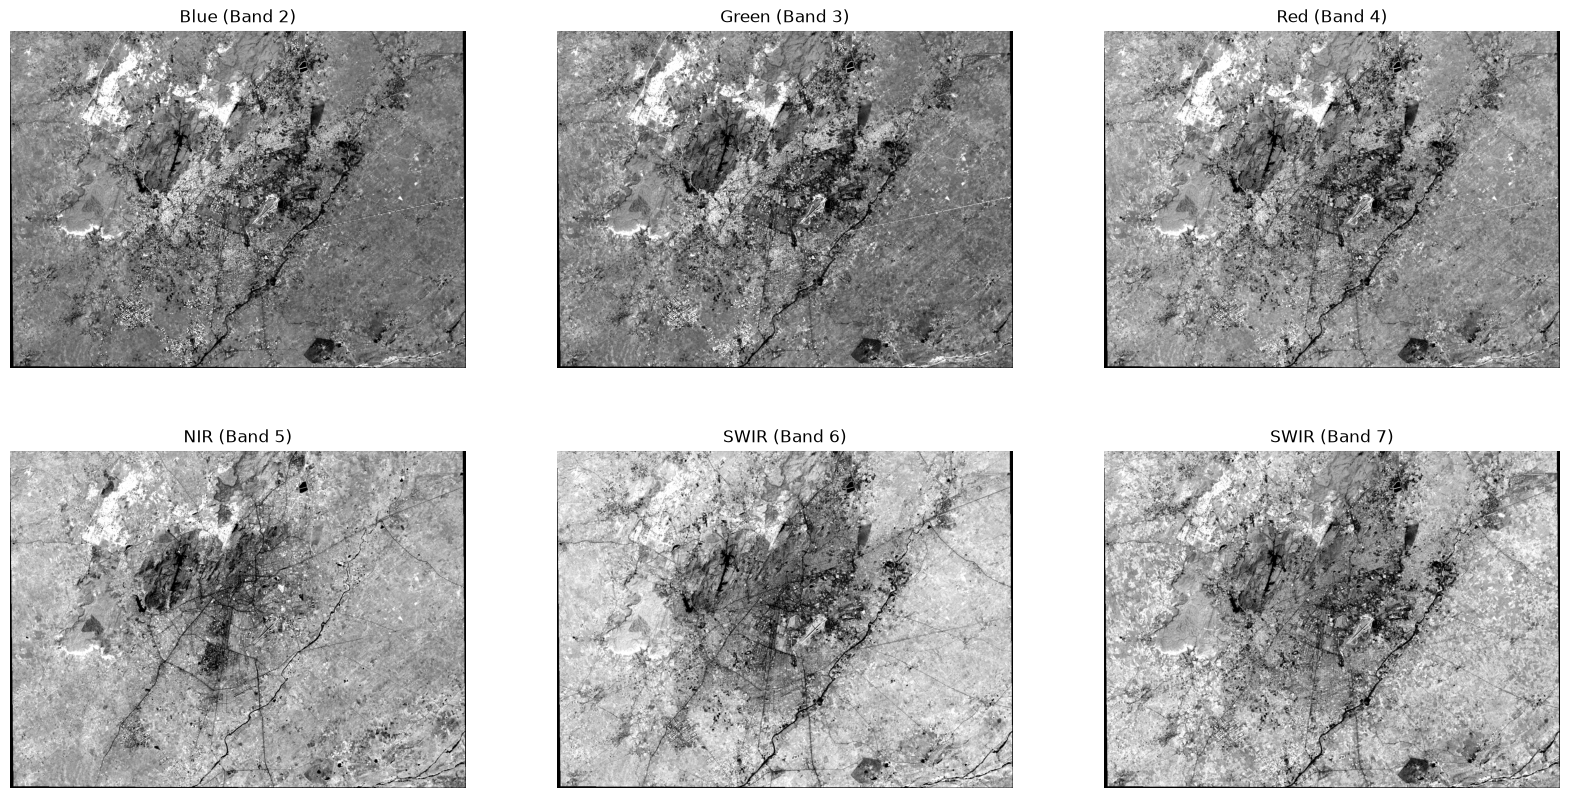

In [ ]:
# Preview Landsat 9 Spectral Bands

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for ax, (title, band_path) in zip(axes.ravel(), bands.items()):
    with rasterio.open(band_path) as src:
        iamge = src.read(1)
        
    # ax.imshow(iamge, cmap='gray')
    vmin, vmax = np.percentile(iamge, (2, 98))
    ax.imshow(iamge, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout
plt.show()

## 6. Generate True Color Composite (TCC)

A True Color Composite (TCC) is generated by assigning the Red, Green, and Blue spectral bands of Landsat 9 to their corresponding display channels. The resulting image closely resembles the natural appearance of the Earth's surface as perceived by the human eye. TCC images are useful for visually identifying urban areas, water bodies, vegetation, and other land-cover features.

For Landsat 9, the True Color Composite is created using:

| Display Channel | Landsat 9 Band |
|-----------------|----------------|
| Red Channel | Band 4 (Red) |
| Green Channel | Band 3 (Green) |
| Blue Channel | Band 2 (Blue) |

To improve visual quality, a percentile-based contrast stretch is applied before displaying the image.

In [43]:
# Read RGB Bands

with rasterio.open(band_4) as src:
    red_band = src.read(1)
    
with rasterio.open(band_3) as src:
    green_band = src.read(1)
    
with rasterio.open(band_2) as src:
    blue_band = src.read(1)

In [44]:
# Apply Contrast Stretching

red_min, red_max = np.percentile(red_band, (2, 98))
green_min, green_max = np.percentile(green_band, (2, 98))
blue_min, blue_max = np.percentile(blue_band, (2, 98))

In [45]:
# Normalize RGB Bands

red = np.clip((red_band - red_min) / (red_max - red_min), 0, 1)
green = np.clip((green_band - green_min) / (green_max - green_min), 0, 1)
blue = np.clip((blue_band - blue_min) / (blue_max - blue_min), 0, 1)


In [46]:
# Create RGB Composite Image

tcc = np.dstack((red, green, blue))

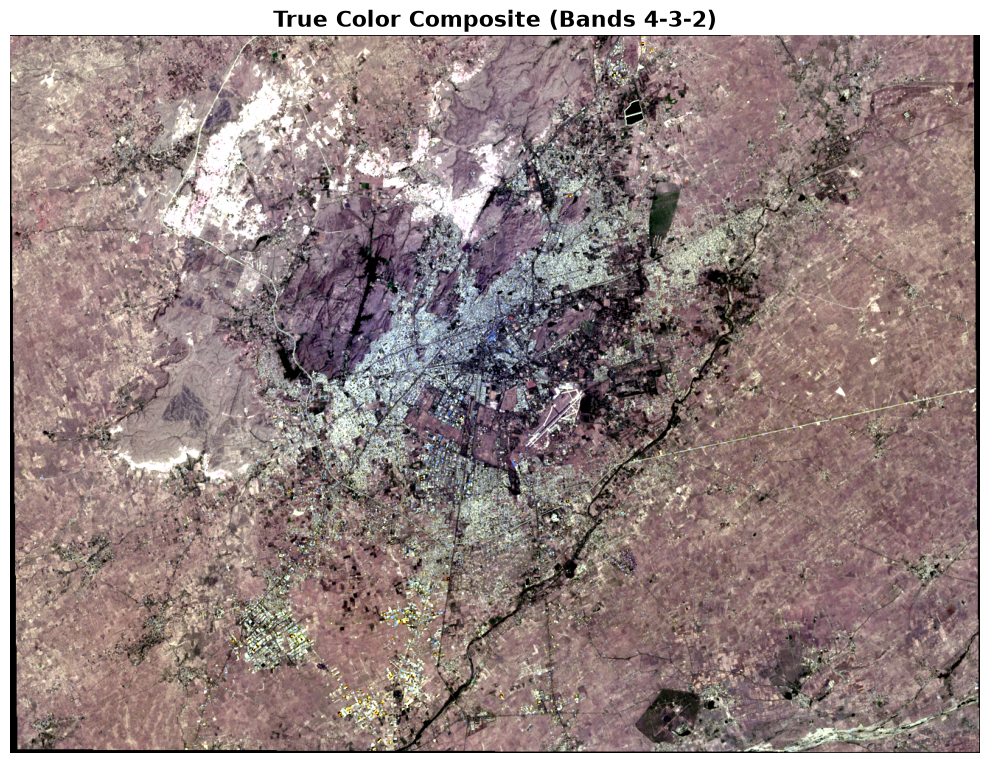

In [47]:
# Display True Color Composite Image

plt.figure(figsize=(10, 10))
plt.imshow(tcc)

plt.title("True Color Composite (Bands 4-3-2)",
          fontsize=16,
          fontweight='bold'
)

plt.axis('off')
plt.tight_layout()

plt.show()

In [49]:
# Save True Color Composite Image

output_path = RGB_OUTPUT / "Jodhpur_True_Color_Composite.png"

plt.imsave(output_path, tcc)

print(f"Image saved successfully at: {output_path}")

Image saved successfully at: d:\Study\#Code Files\#Internships\04 Internship DRDO\Satellite Image Classification Using Machine Learning Techniques\Python\Outputs\RGB_Composite\Jodhpur_True_Color_Composite.png


## 7. Generate False Color Composite (FCC)

A False Color Composite (FCC) is generated by assigning the Near Infrared (NIR), Red, and Green spectral bands of Landsat 9 to the Red, Green, and Blue display channels, respectively. Unlike a True Color Composite, an FCC enhances vegetation by displaying it in shades of red due to the high reflectance of near-infrared radiation from healthy plants.

For Landsat 9, the False Color Composite is created using:

| Display Channel | Landsat 9 Band |
|-----------------|----------------|
| Red Channel | Band 5 (NIR) |
| Green Channel | Band 4 (Red) |
| Blue Channel | Band 3 (Green) |

To improve the visual appearance of the composite, a percentile-based contrast stretch is applied before displaying the image.

In [51]:
# Read FCC Bands

with rasterio.open(band_5) as src:
    nir_band = src.read(1)

with rasterio.open(band_4) as src:
    red_band = src.read(1)

with rasterio.open(band_3) as src:
    green_band = src.read(1)

In [52]:
# Apply Contrast Stretching

nir_min, nir_max = np.percentile(nir_band, (2, 98))
red_min, red_max = np.percentile(red_band, (2, 98))
green_min, green_max = np.percentile(green_band, (2, 98))

In [53]:
# Normalize FCC Bands

nir = np.clip((nir_band - nir_min) / (nir_max - nir_min), 0, 1)
red = np.clip((red_band - red_min) / (red_max - red_min), 0, 1)
green = np.clip((green_band - green_min) / (green_max - green_min), 0, 1)

In [55]:
# Create False Color Composite Image

fcc = np.dstack((nir, red, green))

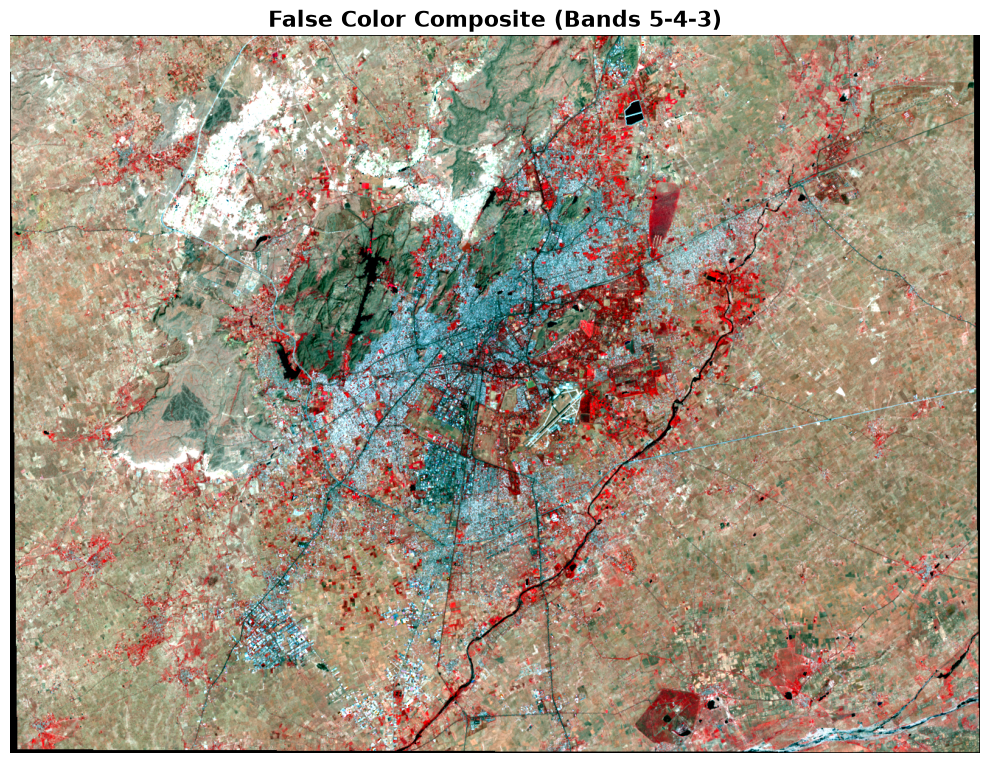

In [56]:
# Display False Color Composite Image

plt.figure(figsize=(10, 10))
plt.imshow(fcc)

plt.title("False Color Composite (Bands 5-4-3)",
          fontsize=16,
          fontweight='bold'
)

plt.axis('off')
plt.tight_layout()

plt.show()

In [57]:
# Save False Color Composite Image

output_path = RGB_OUTPUT / "Jodhpur_False_Color_Composite.png"

plt.imsave(output_path, fcc)

print(f"Image saved successfully at: {output_path}")

Image saved successfully at: d:\Study\#Code Files\#Internships\04 Internship DRDO\Satellite Image Classification Using Machine Learning Techniques\Python\Outputs\RGB_Composite\Jodhpur_False_Color_Composite.png


## 8. Generate NDVI

## 9. Load Training Data and Validation Data

## 10. Extract Training Samples

## 11. Random Forest Classification

## 12. Accuracy Assessment

## 13. Classification Report

## 14. Generate Final Land Cover Map

## 1. Comparision with QGIS